In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *

from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    StringIndexer,
    VectorAssembler,
    StandardScaler
)

from pyspark.ml.classification import (
    LogisticRegression,
    DecisionTreeClassifier,
    RandomForestClassifier,
    GBTClassifier
)

from pyspark.ml.evaluation import (
    MulticlassClassificationEvaluator,
    BinaryClassificationEvaluator
)

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
spark = SparkSession.builder \
    .appName("NYC Taxi Task5") \
    .getOrCreate()

In [3]:
df = spark.read.parquet(
    "yellow_tripdata_2024-01.parquet",
    "yellow_tripdata_2024-02.parquet",
    "yellow_tripdata_2024-03.parquet",
    "yellow_tripdata_2024-04.parquet"
)

Preprocessing

In [4]:
df = df.fillna({
    "passenger_count":1,
    "RatecodeID":1,
    "congestion_surcharge":0,
    "Airport_fee":0
})

df = df.fillna({
    "store_and_fwd_flag":"N"
})

In [5]:
df = df.withColumn(
    "trip_duration",
    (
        unix_timestamp("tpep_dropoff_datetime")
        -
        unix_timestamp("tpep_pickup_datetime")
    ) / 60
)

df = df.withColumn(
    "pickup_hour",
    hour("tpep_pickup_datetime")
)

df = df.withColumn(
    "pickup_day",
    dayofweek("tpep_pickup_datetime")
)

df = df.withColumn(
    "is_weekend",
    when(
        col("pickup_day").isin([1,7]),
        1
    ).otherwise(0)
)

df = df.withColumn(
    "high_tip",
    when(
        col("tip_amount") >= 5,
        1
    ).otherwise(0)
)

In [6]:
df = df.filter(col("trip_distance") > 0)
df = df.filter(col("fare_amount") > 0)
df = df.filter(col("trip_duration") > 0)

Feature Pipeline

In [7]:
indexer = StringIndexer(
    inputCol="payment_type",
    outputCol="payment_type_index"
)

feature_columns = [
    "passenger_count",
    "trip_distance",
    "fare_amount",
    "PULocationID",
    "DOLocationID",
    "payment_type_index",
    "pickup_hour",
    "pickup_day",
    "is_weekend",
    "trip_duration"
]

assembler = VectorAssembler(
    inputCols=feature_columns,
    outputCol="assembled_features"
)

scaler = StandardScaler(
    inputCol="assembled_features",
    outputCol="features"
)

pipeline = Pipeline(
    stages=[
        indexer,
        assembler,
        scaler
    ]
)

pipeline_model = pipeline.fit(df)

final_df = pipeline_model.transform(df)

Train/Test Split

In [8]:
train_df, test_df = final_df.randomSplit(
    [0.8,0.2],
    seed=42
)

# Train Best Model

Using Random Forest

In [9]:
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="high_tip",
    numTrees=50,
    maxDepth=10
)

rf_model = rf.fit(train_df)

predictions = rf_model.transform(test_df)

In [10]:
accuracy = MulticlassClassificationEvaluator(
    labelCol="high_tip",
    predictionCol="prediction",
    metricName="accuracy"
).evaluate(predictions)

print("Accuracy:", accuracy)

Accuracy: 0.9285979860757223


In [11]:
precision = MulticlassClassificationEvaluator(
    labelCol="high_tip",
    predictionCol="prediction",
    metricName="weightedPrecision"
).evaluate(predictions)

print("Precision:", precision)

Precision: 0.9290485254027853


In [12]:
recall = MulticlassClassificationEvaluator(
    labelCol="high_tip",
    predictionCol="prediction",
    metricName="weightedRecall"
).evaluate(predictions)

print("Recall:", recall)

Recall: 0.9285979860757223


In [13]:
f1 = MulticlassClassificationEvaluator(
    labelCol="high_tip",
    predictionCol="prediction",
    metricName="f1"
).evaluate(predictions)

print("F1:", f1)

F1: 0.9288118101278529


In [14]:
auc = BinaryClassificationEvaluator(
    labelCol="high_tip",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
).evaluate(predictions)

print("ROC AUC:", auc)

ROC AUC: 0.9547216275380404


In [15]:
predictions.groupBy(
    "high_tip",
    "prediction"
).count().show()

+--------+----------+-------+
|high_tip|prediction|  count|
+--------+----------+-------+
|       1|       0.0|  86516|
|       0|       0.0|1965535|
|       1|       1.0| 379655|
|       0|       1.0|  93811|
+--------+----------+-------+



Stability Analysis

In [16]:
noise_df = final_df.withColumn(
    "passenger_count",
    col("passenger_count") + rand()
)

In [17]:
noise_train, noise_test = noise_df.randomSplit(
    [0.8,0.2],
    seed=42
)

noise_model = rf.fit(noise_train)

noise_predictions = noise_model.transform(
    noise_test
)

noise_accuracy = MulticlassClassificationEvaluator(
    labelCol="high_tip",
    predictionCol="prediction",
    metricName="accuracy"
).evaluate(noise_predictions)

print("Noisy Accuracy:", noise_accuracy)

Noisy Accuracy: 0.9287080625471933


Feature Importance (Explainability)

In [18]:
importance = rf_model.featureImportances

print(importance)

(10,[0,1,2,3,4,5,6,7,8,9],[0.0012502062980455611,0.23348227610631525,0.3498958253046681,0.009649682405822667,0.0031445584775630655,0.24911036549305204,0.007531431233660612,0.0003548509615744433,0.0011340836845040276,0.14444672003479422])


In [19]:
importance_values = list(
    importance.toArray()
)

importance_df = pd.DataFrame(
    {
        "Feature":feature_columns,
        "Importance":importance_values
    }
)

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df

,Feature,Importance
2,fare_amount,0.349896
5,payment_type_index,0.249110
1,trip_distance,0.233482
9,trip_duration,0.144447
3,PULocationID,0.009650
6,pickup_hour,0.007531
4,DOLocationID,0.003145
0,passenger_count,0.001250
8,is_weekend,0.001134
7,pickup_day,0.000355


Feature Importance Chart

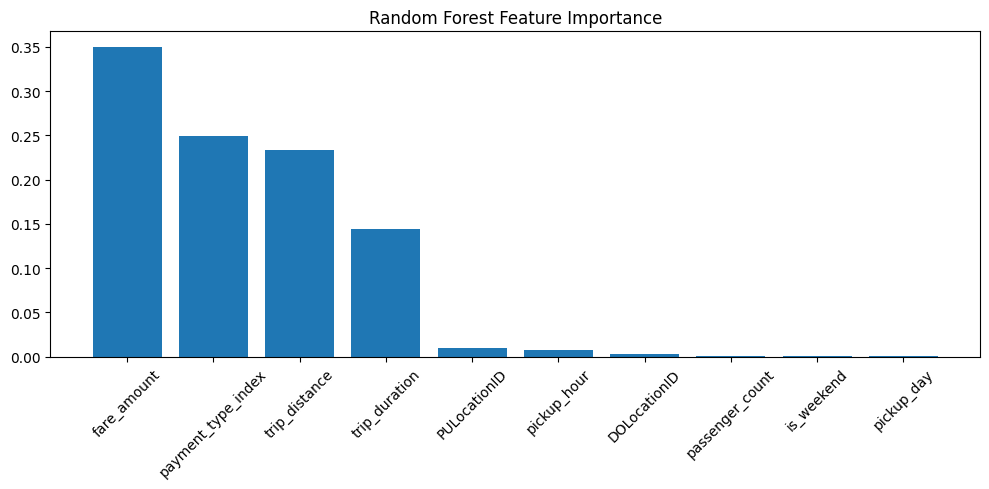

In [20]:
plt.figure(figsize=(10,5))

plt.bar(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xticks(rotation=45)

plt.title(
    "Random Forest Feature Importance"
)

plt.tight_layout()

plt.show()

In [21]:
importance_df.to_csv(
    "feature_importance.csv",
    index=False
)

print(
    "Feature Importance Exported"
)

Feature Importance Exported


In [22]:
model_metrics = pd.read_csv(
    "model_metrics.csv"
)

feature_importance = pd.read_csv(
    "feature_importance.csv"
)

stability_metrics = pd.read_csv(
    "stability_metrics.csv"
)

scalability_metrics = pd.read_csv(
    "scalability_metrics.csv"
)

In [27]:
print(model_metrics.head())

print('=========================')

print(feature_importance.head())

print('=========================')

print(stability_metrics.head())

print('=========================')

print(scalability_metrics.head())

                 Model  Accuracy  Precision    Recall        F1   ROC_AUC
0  Logistic Regression  0.879920   0.872363  0.879920  0.867902  0.929521
1        Decision Tree  0.930708   0.931964  0.930708  0.931255  0.855758
2        Random Forest  0.930534   0.931502  0.930534  0.930967  0.955584
3                  GBT  0.931351   0.932274  0.931351  0.931765  0.958407
              Feature  Importance
0         fare_amount    0.349896
1  payment_type_index    0.249110
2       trip_distance    0.233482
3       trip_duration    0.144447
4        PULocationID    0.009650
  Model  Accuracy
0    LR  0.879920
1    DT  0.930708
2    RF  0.930534
3   GBT  0.931351
          Metric  Execution_Time
0  Without Cache        4.063379
1     With Cache        1.559371
2  Repartitioned        4.612051


Dashboard 1

Data Quality & Pipeline Monitoring

In [28]:
df = spark.read.parquet(
    "yellow_tripdata_2024-01.parquet",
    "yellow_tripdata_2024-02.parquet",
    "yellow_tripdata_2024-03.parquet",
    "yellow_tripdata_2024-04.parquet"
)

In [29]:
data_quality = pd.DataFrame(
    {
        "Metric":[
            "Rows",
            "Columns",
            "Missing Columns"
        ],
        "Value":[
            13069067,
            19,
            5
        ]
    }
)

data_quality.to_csv(
    "dashboard1_data_quality.csv",
    index=False
)

Dashboard 2

Model Performance & Feature Importance

In [30]:
model_metrics.to_csv(
    "dashboard2_model_metrics.csv",
    index=False
)

feature_importance.to_csv(
    "dashboard2_feature_importance.csv",
    index=False
)

# Dashboard 3

Business Insights

In [31]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *

spark = SparkSession.builder \
    .appName("Business Insights") \
    .getOrCreate()

In [32]:
df = spark.read.parquet(
    "yellow_tripdata_2024-01.parquet",
    "yellow_tripdata_2024-02.parquet",
    "yellow_tripdata_2024-03.parquet",
    "yellow_tripdata_2024-04.parquet"
)

Insight 1

Hourly Demand

In [33]:
hourly_demand = df.withColumn(
    "pickup_hour",
    hour("tpep_pickup_datetime")
)

hourly_demand = hourly_demand.groupBy(
    "pickup_hour"
).count().orderBy(
    "pickup_hour"
)

hourly_demand_pd = hourly_demand.toPandas()

In [34]:
hourly_demand_pd.to_csv(
    "dashboard3_hourly_demand.csv",
    index=False
)

Insight 2

Average Fare By Hour

In [35]:
fare_hour = df.withColumn(
    "pickup_hour",
    hour("tpep_pickup_datetime")
)

fare_hour = fare_hour.groupBy(
    "pickup_hour"
).agg(
    avg("fare_amount")
    .alias("avg_fare")
)

fare_hour_pd = fare_hour.toPandas()

In [36]:
fare_hour_pd.to_csv(
    "dashboard3_avg_fare_hour.csv",
    index=False
)

Insight 3

Average Tip By Payment Type

In [37]:
tip_payment = df.groupBy(
    "payment_type"
).agg(
    avg("tip_amount")
    .alias("avg_tip")
)

tip_payment_pd = tip_payment.toPandas()

In [38]:
tip_payment_pd.to_csv(
    "dashboard3_tip_by_payment.csv",
    index=False
)

Insight 4

Top Pickup Locations

In [39]:
top_pickups = df.groupBy(
    "PULocationID"
).count().orderBy(
    desc("count")
).limit(20)

top_pickups_pd = top_pickups.toPandas()

In [40]:
top_pickups_pd.to_csv(
    "dashboard3_top_pickups.csv",
    index=False
)

# Dashboard 4
Scalability & Cost Analysis

In [41]:
scalability_metrics.to_csv(
    "dashboard4_scalability.csv",
    index=False
)

In [42]:
cost_analysis = scalability_metrics.copy()

cost_analysis.to_csv(
    "dashboard4_cost_analysis.csv",
    index=False
)

Final Verification

In [44]:
import os

csv_files = [
    f for f in os.listdir()
    if f.startswith("dashboard")
]

for f in csv_files:
    print(f)

dashboard3_hourly_demand.csv
dashboard3_avg_fare_hour.csv
dashboard2_feature_importance.csv
dashboard3_tip_by_payment.csv
dashboard4_cost_analysis.csv
dashboard4_scalability.csv
dashboard3_top_pickups.csv
dashboard2_model_metrics.csv
dashboard1_data_quality.csv
